In [1]:
library(ggplot2)
library(ggrepel)
library(ggpubr)
library(stringr)
library(MASS)
library(RColorBrewer)
library(DESeq2)
library(viridis)
library(ggpointdensity)
library(tidyverse)
library(data.table)
library(pheatmap)
library(ComplexHeatmap)
library(UpSetR)
library(readxl)
library(ggsci)
library(ggprism)
library(ragg)
library(edgeR)
theme_set(theme_classic(base_size = 15))

personal_path = "/fh/working/sun_w/sshen/MorPhiC"
path = "/fh/fast/sun_w/MorPhiC/data/MorPhiC_exchange_experiment/"
dat_path = file.path(path, "DRACC-processed/MSK_exchange_experiment_DRACC_processed_March_2026/Tables")

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The follo

In [2]:
meta = fread(file.path(personal_path, "MSK_meta_data.tsv"), data.table = FALSE)
meta$ko_gene[meta$Dcondition == "UCSF_DOX"] = "WT"
meta$ko_gene[meta$Dcondition == "NWU_IAA"] = "WT"

In [3]:
cts = fread(file.path(dat_path, "genesCounts.csv"), data.table = FALSE)
colnames(cts) <- gsub("_S[0-9]+_L[0-9]+$", "", colnames(cts))
# Align counts with meta data
stopifnot(
  setequal(meta$Name, names(cts)[-1]),
  !any(duplicated(meta$Name)),
  !any(duplicated(names(cts)[-1]))
)
meta = meta[match(names(cts)[-1], meta$Name), ]
# To matrix
cts_dat = data.matrix(cts[, -1])
rownames(cts_dat) = cts$Name

In [4]:
# Read in gene annotation
gene_anno = fread("/fh/fast/sun_w/sshen/MorPhiC/gencode_v44_primary_assembly_info.tsv")
dim(gene_anno)
cts = cts[cts$Name %in% gene_anno$ensembl_gene_id, ]
cts_dat = cts_dat[rownames(cts_dat) %in% gene_anno$ensembl_gene_id, ]

gene_info = data.frame(
  apply(cts_dat, 1, min), 
  apply(cts_dat, 1, median), 
  apply(cts_dat, 1, \(x) quantile(x, probs = 0.75)), 
  apply(cts_dat, 1, max)
)
gene_info[1:2, ]
names(gene_info) = c("min", "median", "q75", "max")
summary(gene_info)
table(gene_info$q75 > 0)

# Subset genes
w2kp = which(gene_info$q75 > 0)
cts_dat = cts_dat[w2kp, ]
gene_info = gene_info[w2kp, ]


[1] 62754     8

,apply.cts_dat..1..min.,apply.cts_dat..1..median.,apply.cts_dat..1..function.x..quantile.x..probs...0.75..,apply.cts_dat..1..max.
,<int>,<int>,<dbl>,<int>
ENSG00000268674,0,0,0,0
ENSG00000271254,291,829,1051,2669


      min               median              q75                max        
 Min.   :     0.0   Min.   :     0.0   Min.   :     0.0   Min.   :     0  
 1st Qu.:     0.0   1st Qu.:     0.0   1st Qu.:     0.0   1st Qu.:     1  
 Median :     0.0   Median :     1.0   Median :     3.5   Median :    13  
 Mean   :   242.1   Mean   :   543.8   Mean   :   725.1   Mean   :  1439  
 3rd Qu.:    68.0   3rd Qu.:   227.0   3rd Qu.:   328.0   3rd Qu.:   694  
 Max.   :179525.0   Max.   :249211.0   Max.   :290383.0   Max.   :581619  


FALSE  TRUE 
15492 23100 

## Match association data

In [5]:
scripts_path = "/fh/working/sun_w/sshen/Code/MorPhiC/exchange-experiment-analysis/scripts"
eomes_assoc = readxl::read_excel(file.path(scripts_path, "EOMES_Association.xlsx"), .name_repair = "unique") %>%
  mutate(
    Institution = stringr::str_squish(as.character(Institution)),
    Sample = stringr::str_squish(as.character(Sample)),
    association_institution = case_when(
      str_to_lower(Institution) == "northwestern" ~ "Northwestern",
      TRUE ~ Institution
    ),
    association_sample_key = str_to_lower(str_replace_all(Sample, "\\s+", "")),
    association_key = paste(str_to_lower(association_institution), association_sample_key, sep = "|")
  )

make_eomes_association_sample = function(center, dcondition, replicate) {
  replicate = as.character(replicate)
  case_when(
    center == "Parent" & dcondition == "KOLF" ~ paste0("KOLF2.2J- WT ", replicate),
    center == "MSK" & str_detect(dcondition, "^MSK_KO_\\d+$") ~ paste0("#", str_match(dcondition, "^MSK_KO_(\\d+)$")[, 2], "-", replicate),
    center == "JAX" & str_detect(dcondition, "^JAX_KO_\\d+$") ~ paste0("#", str_match(dcondition, "^JAX_KO_(\\d+)$")[, 2], "-", replicate),
    center == "NorthWestern" & dcondition == "NWU" ~ paste0("Parental ", replicate, " -IAA"),
    center == "NorthWestern" & dcondition == "NWU_IAA" ~ paste0("Parental ", replicate, " +IAA"),
    center == "NorthWestern" & str_detect(dcondition, "^NWU_KO_\\d+$") ~ paste0("#", str_match(dcondition, "^NWU_KO_(\\d+)$")[, 2], "-", replicate, " -IAA"),
    center == "NorthWestern" & str_detect(dcondition, "^NWU_\\d+_KO$") ~ paste0("#", str_match(dcondition, "^NWU_(\\d+)_KO$")[, 2], "-", replicate, " -IAA"),
    center == "NorthWestern" & str_detect(dcondition, "^KO_\\d+_IAA$") ~ paste0("#", str_match(dcondition, "^KO_(\\d+)_IAA$")[, 2], "-", replicate, " +IAA"),
    center == "UCSF" & dcondition == "UCSF" ~ paste0("Parental ", replicate, " -Dox"),
    center == "UCSF" & dcondition == "UCSF_DOX" ~ paste0("Parental ", replicate, " +Dox"),
    center == "UCSF" & dcondition == "UCSF_KO_9" ~ paste0("EOMES CRISPRi Clone - ", replicate, " -Dox"),
    center == "UCSF" & dcondition == "KO_9_DOX" ~ paste0("EOMES CRISPRi Clone - ", replicate, " +Dox"),
    TRUE ~ NA_character_
  )
}

meta = meta %>%
  select(-any_of(c("association_institution", "association_sample", "association_sample_key", "association_key", "Sox17+MFI", "Sox17+"))) %>%
  mutate(
    association_institution = case_when(
      Center == "Parent" ~ "MSK",
      Center == "NorthWestern" ~ "Northwestern",
      TRUE ~ Center
    ),
    association_sample = make_eomes_association_sample(Center, Dcondition, Replicate),
    association_sample_key = str_to_lower(str_replace_all(association_sample, "\\s+", "")),
    association_key = paste(str_to_lower(association_institution), association_sample_key, sep = "|")
  ) %>%
  left_join(
    eomes_assoc %>% select(association_key, `Sox17+MFI`, `Sox17+`),
    by = "association_key"
  )

eomes_assoc_unmatched = anti_join(
  eomes_assoc,
  meta %>% filter(!is.na(association_key)) %>% distinct(association_key),
  by = "association_key"
)
meta_eomes_unmatched = meta %>%
  filter(is.na(`Sox17+`)) %>%
  select(Name, Center, Dcondition, Replicate, association_sample)

stopifnot(nrow(eomes_assoc_unmatched) == 0)
table(!is.na(meta$`Sox17+`))
meta %>% select(Name, Center, Dcondition, Replicate, association_sample, `Sox17+MFI`, `Sox17+`) %>% head()
meta_eomes_unmatched


TRUE 
  51 

,Name,Center,Dcondition,Replicate,association_sample,Sox17+MFI,Sox17+
,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>
1,KOLF_2_1_val,Parent,KOLF,2,KOLF2.2J- WT 2,12131,98.100
2,NWU_KO_2_1_1_val,NorthWestern,NWU_KO_2,1,#2-1 -IAA,1902,10.610
3,MSK_KO_9_3_1_val,MSK,MSK_KO_9,3,#9-3,323,5.570
4,KOLF2_3_1_val,Parent,KOLF,3,KOLF2.2J- WT 3,9713,98.700
5,KOLF_1_1_val,Parent,KOLF,1,KOLF2.2J- WT 1,10706,98.280
6,KO_46_IAA_3_1_val,NorthWestern,KO_46_IAA,3,#46-3 +IAA,950,3.925


Name,Center,Dcondition,Replicate,association_sample
<chr>,<chr>,<chr>,<int>,<chr>


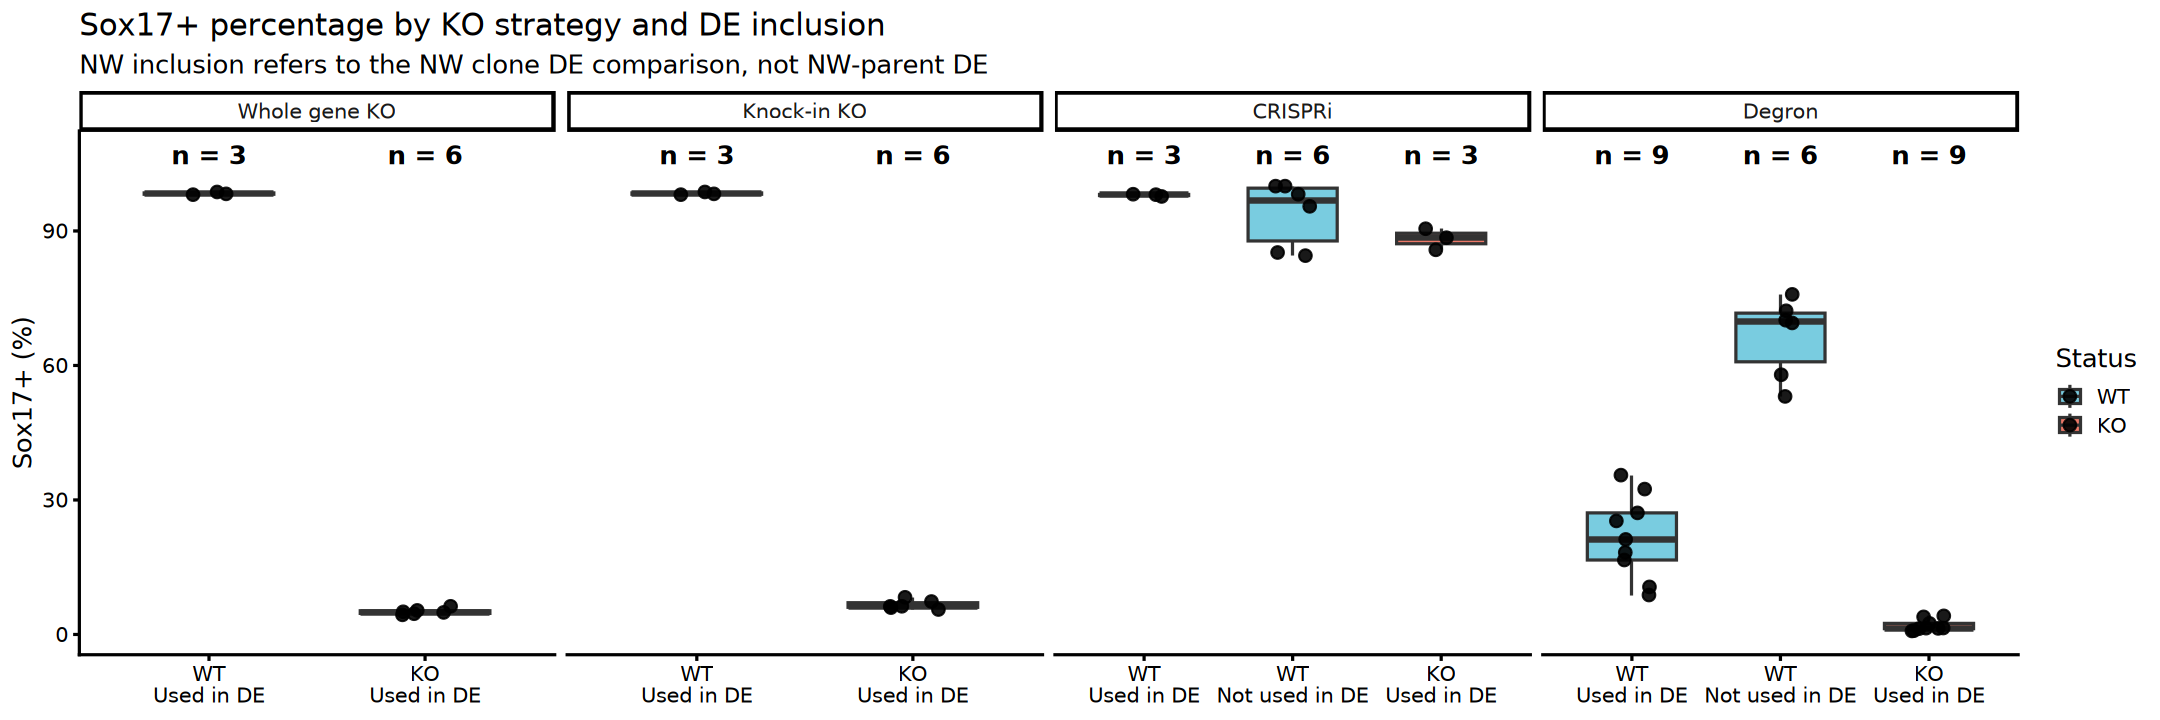

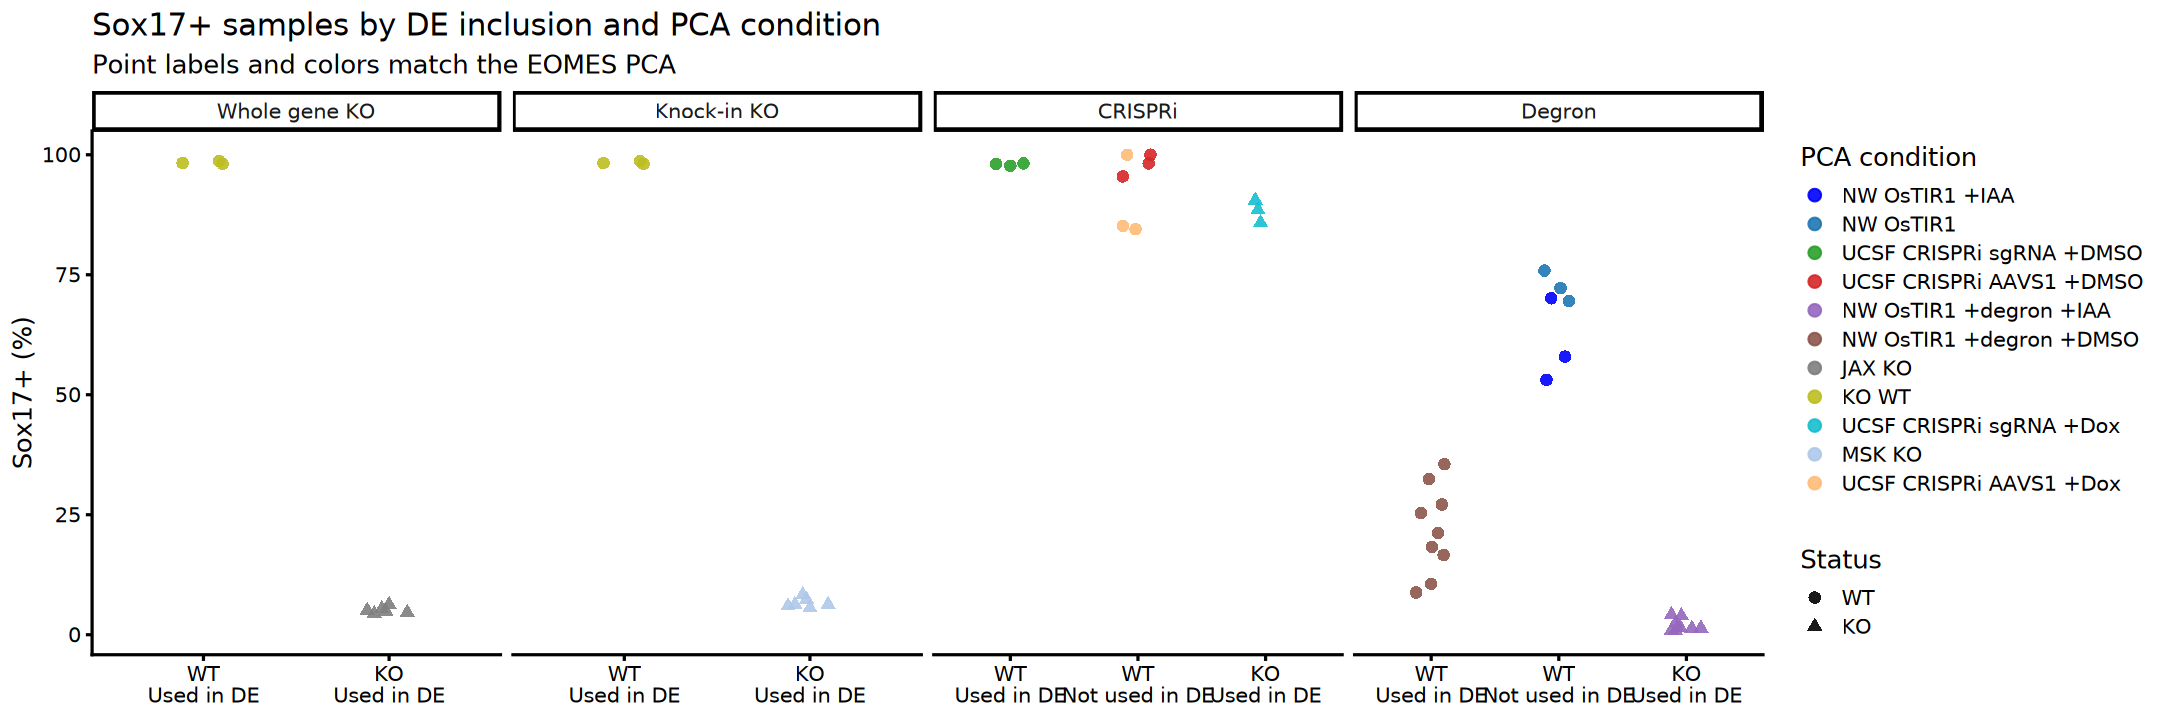

,ensembl_gene_id,logFC,AveExpr,t,P.Value,qvalue,B
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000153904,-1.925823,6.275078,-17.69673,3.652333e-23,2.658509e-19,42.55540
2,ENSG00000169439,-1.987481,6.778831,-17.42779,7.069671e-23,2.658509e-19,41.91030
3,ENSG00000102024,-1.453456,8.531146,-17.17743,1.316143e-22,3.299520e-19,41.28388
4,ENSG00000196141,-2.121087,7.513493,-16.74025,3.957759e-22,7.441463e-19,40.19501
5,ENSG00000171310,1.970355,5.167930,16.64004,5.108446e-22,7.684007e-19,39.94615
6,ENSG00000072832,-1.541487,6.461233,-16.51620,7.013168e-22,8.761063e-19,39.63005
7,ENSG00000020577,-2.679193,5.813415,-16.41329,9.137330e-22,8.761063e-19,39.31438
8,ENSG00000119711,1.099893,5.158561,16.40565,9.319183e-22,8.761063e-19,39.34897
9,ENSG00000163430,-1.125900,9.992461,-16.20022,1.586126e-21,1.325452e-18,38.78834


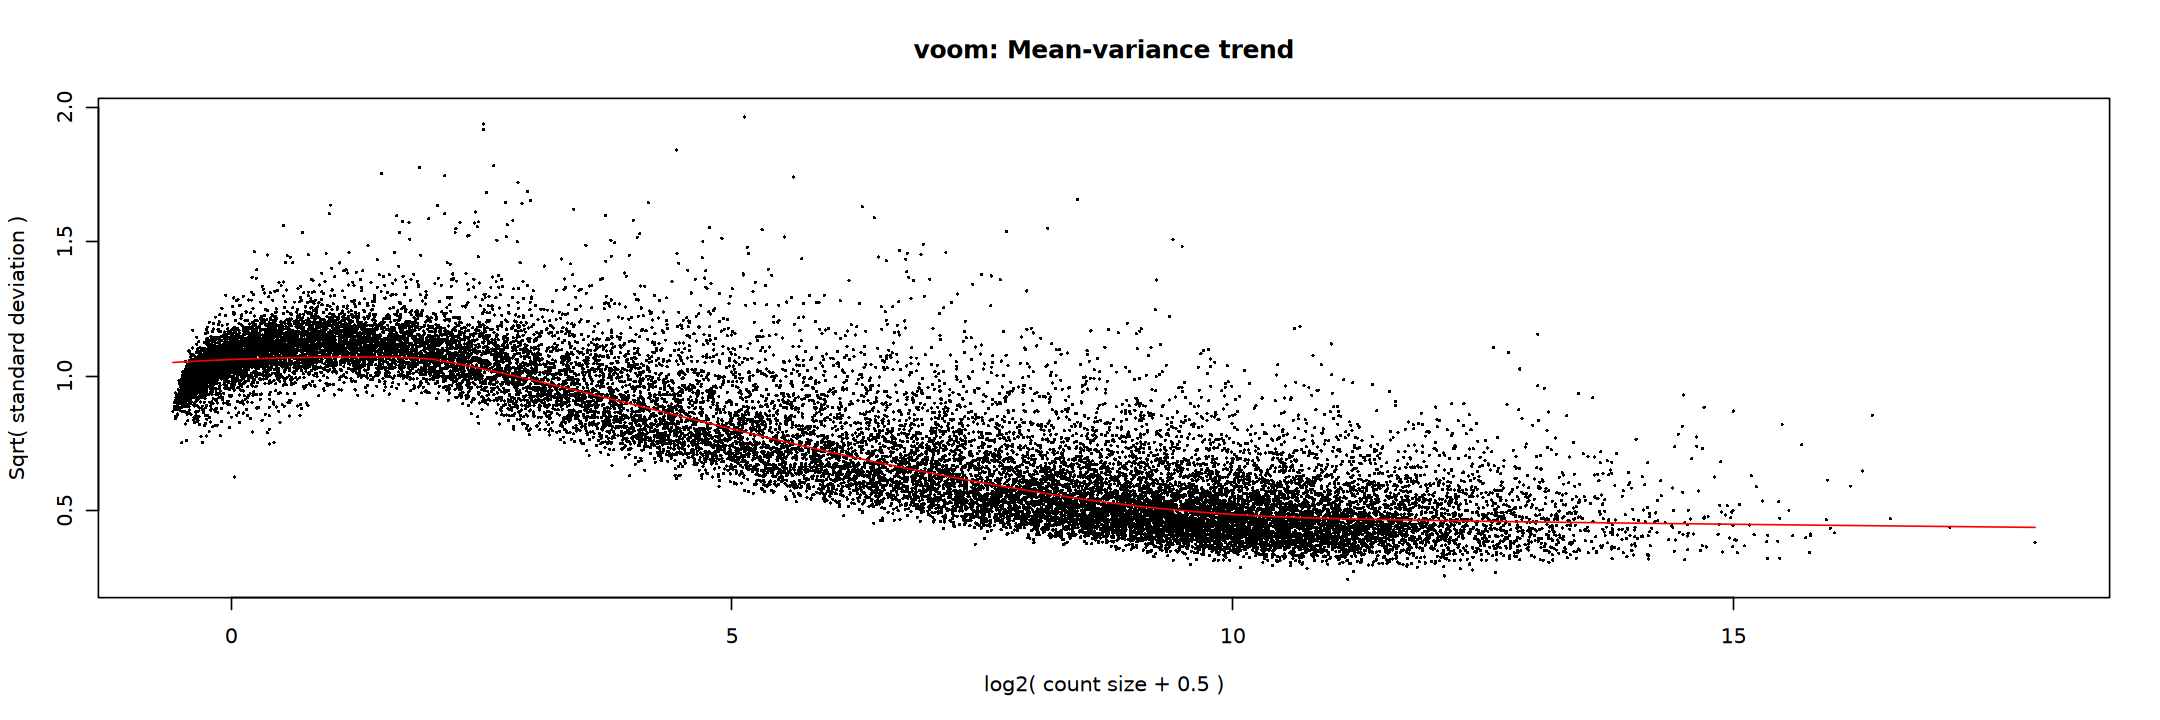

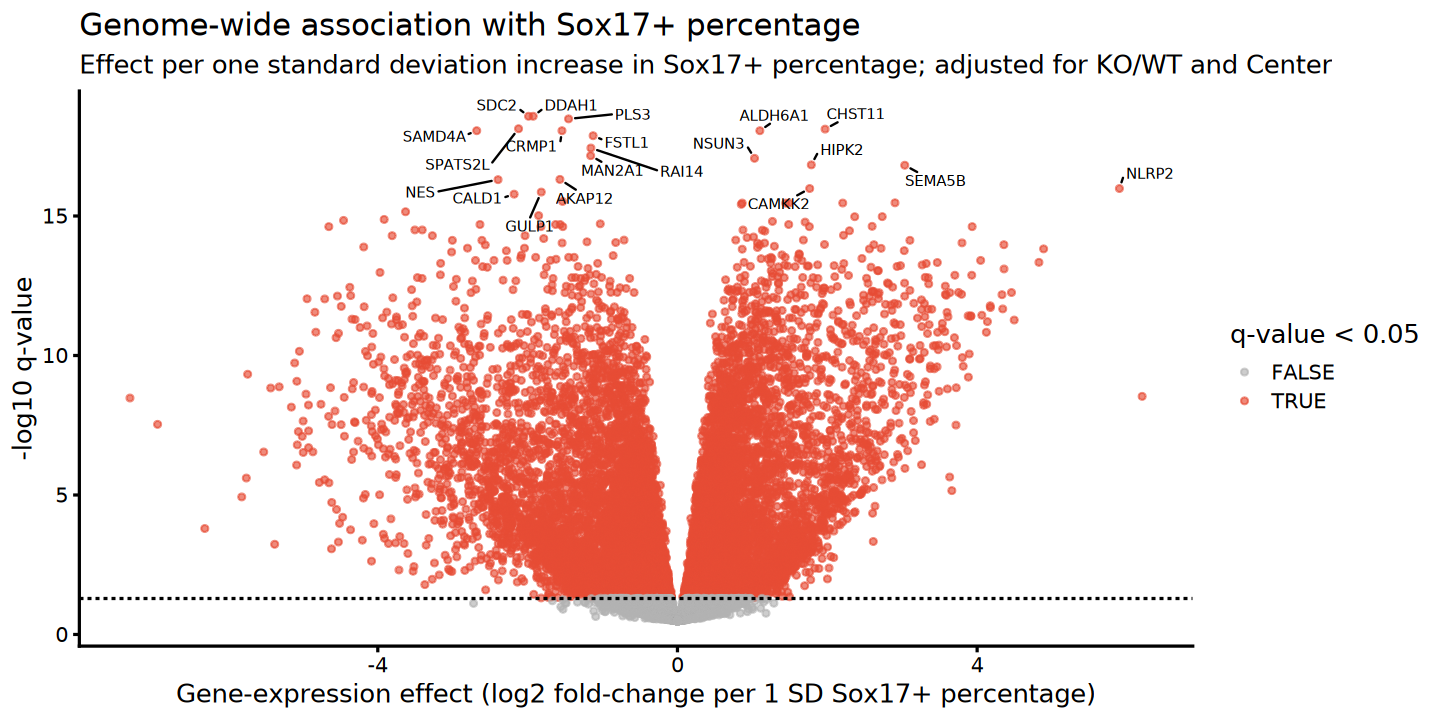

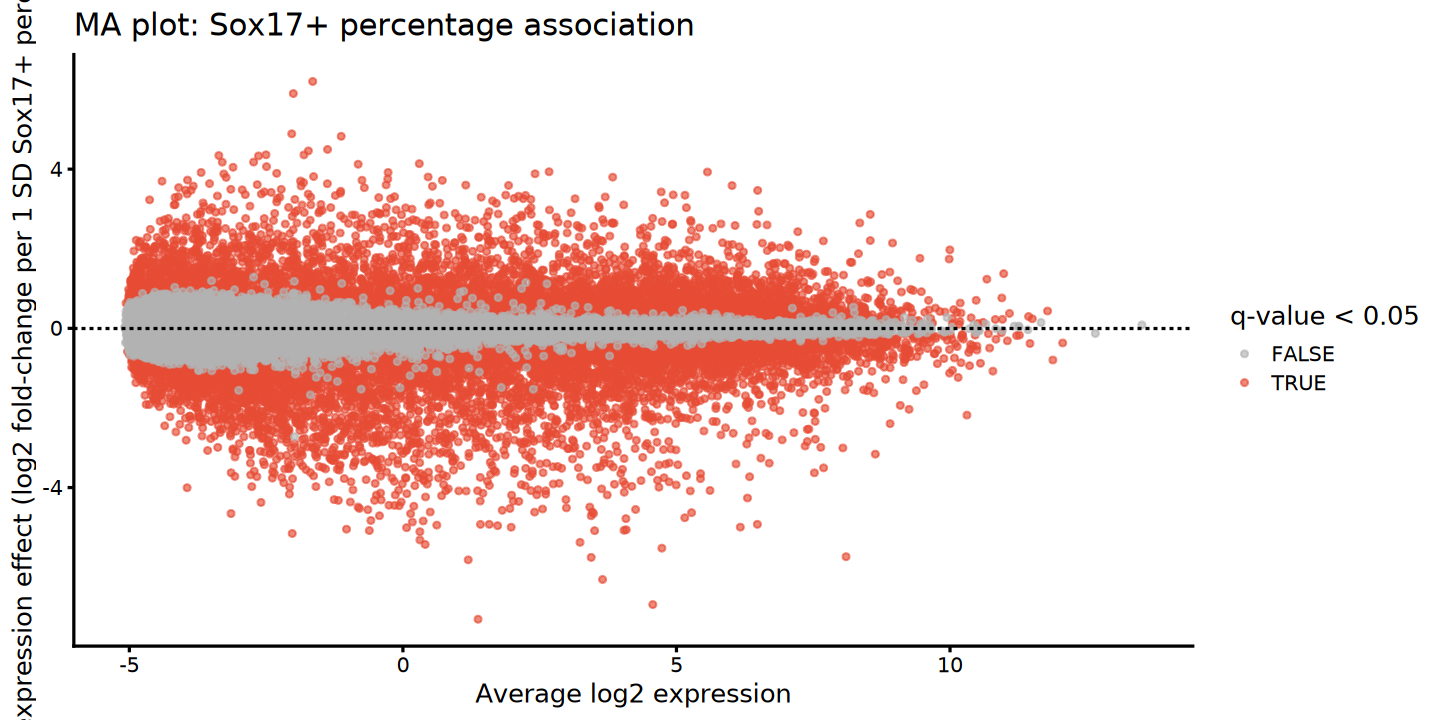

In [6]:
# Sox17+ percentage association analysis
# Each gene is modeled as a response to scaled Sox17+ percentage while adjusting
# for KO/WT status and Center.
assoc_meta <- meta[!is.na(meta$`Sox17+`), ] %>%
  filter(ko_gene %in% c("WT", "KO")) %>%
  mutate(
    ko_wt = factor(ko_gene, levels = c("WT", "KO")),
    ko_strategy = factor(
      case_when(
        Center == "JAX" ~ "Whole gene KO",
        Center == "MSK" ~ "Knock-in KO",
        Center == "UCSF" ~ "CRISPRi",
        Center == "NorthWestern" ~ "Degron",
        Center == "Parent" ~ "KOLF parent",
        TRUE ~ as.character(Center)
      ),
      levels = c("KOLF parent", "Whole gene KO", "Knock-in KO", "CRISPRi", "Degron")
    ),
    de_inclusion = factor(
      case_when(
        Center == "JAX" & Dcondition %in% c("JAX_KO_10", "JAX_KO_12") ~ "Used in DE",
        Center == "MSK" & Dcondition %in% c("MSK_KO_2", "MSK_KO_9") ~ "Used in DE",
        Center == "UCSF" & Dcondition %in% c("UCSF_KO_9", "KO_9_DOX") ~ "Used in DE",
        # NW here means the NW clone DE comparison only, not NW-parent DE.
        Center == "NorthWestern" & Dcondition %in% c("NWU_KO_2", "NWU_KO_45", "NWU_46_KO", "KO_2_IAA", "KO_45_IAA", "KO_46_IAA") ~ "Used in DE",
        Center == "Parent" & Dcondition == "KOLF" ~ "Used in DE",
        TRUE ~ "Not used in DE"
      ),
      levels = c("Used in DE", "Not used in DE")
    ),
    Center = factor(Center),
    Sox17_percent_scaled = as.numeric(scale(`Sox17+`))
  ) %>%
  arrange(match(Name, colnames(cts_dat)))

stopifnot(
  nrow(assoc_meta) > 0,
  !anyNA(assoc_meta$Name),
  !anyDuplicated(assoc_meta$Name),
  all(assoc_meta$Name %in% colnames(cts_dat)),
  !anyNA(assoc_meta$Sox17_percent_scaled),
  !anyNA(assoc_meta$ko_strategy),
  !anyNA(assoc_meta$de_inclusion)
)

assoc_counts <- cts_dat[, assoc_meta$Name, drop = FALSE]
stopifnot(identical(colnames(assoc_counts), assoc_meta$Name))

# The KOLF-parent samples are used only in the JAX and MSK DE comparisons.
# Do not show them in the UCSF CRISPRi or NW degron facets.
strategy_levels <- c("Whole gene KO", "Knock-in KO", "CRISPRi", "Degron")
parent_control_strategies <- c("Whole gene KO", "Knock-in KO")

# Match the EOMES PCA's condition labels and named color palette exactly.
pca_label_map <- c(
  "UCSF" = "UCSF CRISPRi AAVS1 +DMSO",
  "UCSF_DOX" = "UCSF CRISPRi AAVS1 +Dox",
  "UCSF_KO_9" = "UCSF CRISPRi sgRNA +DMSO",
  "KO_9_DOX" = "UCSF CRISPRi sgRNA +Dox",
  "NWU" = "NW OsTIR1",
  "NWU_IAA" = "NW OsTIR1 +IAA",
  "NWU_KO_2" = "NW OsTIR1 +degron +DMSO",
  "KO_2_IAA" = "NW OsTIR1 +degron +IAA",
  "NWU_KO_45" = "NW OsTIR1 +degron +DMSO",
  "KO_45_IAA" = "NW OsTIR1 +degron +IAA",
  "NWU_46_KO" = "NW OsTIR1 +degron +DMSO",
  "KO_46_IAA" = "NW OsTIR1 +degron +IAA",
  "JAX_KO_10" = "JAX KO",
  "JAX_KO_12" = "JAX KO",
  "MSK_KO_2" = "MSK KO",
  "MSK_KO_9" = "MSK KO",
  "KOLF" = "KO WT"
)
pca_colors <- c("blue", paletteer::paletteer_d("ggsci::category20_d3")[1:12])
names(pca_colors) <- c(
  "NW OsTIR1 +IAA", "NW OsTIR1", "UCSF CRISPRi WT",
  "UCSF CRISPRi sgRNA +DMSO", "UCSF CRISPRi AAVS1 +DMSO",
  "NW OsTIR1 +degron +IAA", "NW OsTIR1 +degron +DMSO", "NW WT",
  "JAX KO", "KO WT", "UCSF CRISPRi sgRNA +Dox", "MSK KO",
  "UCSF CRISPRi AAVS1 +Dox"
)

sox17_plot_meta <- bind_rows(
  assoc_meta %>%
    filter(Center != "Parent"),
  assoc_meta %>%
    filter(Center == "Parent") %>%
    select(-ko_strategy) %>%
    tidyr::crossing(ko_strategy = parent_control_strategies)
) %>%
  mutate(
    ko_strategy = factor(ko_strategy, levels = strategy_levels),
    box_group = factor(
      paste(ko_wt, de_inclusion, sep = "\n"),
      levels = c(
        "WT\nUsed in DE", "WT\nNot used in DE",
        "KO\nUsed in DE", "KO\nNot used in DE"
      )
    ),
    pca_label = factor(
      unname(pca_label_map[as.character(Dcondition)]),
      levels = names(pca_colors)
    )
  )

stopifnot(!anyNA(sox17_plot_meta$pca_label))

sox17_group_counts <- sox17_plot_meta %>%
  count(ko_strategy, box_group) %>%
  mutate(
    label = paste0("n = ", n),
    y = max(sox17_plot_meta$`Sox17+`) * 1.07
  )

sox17_ko_wt_plot <- ggplot(sox17_plot_meta, aes(x = box_group, y = `Sox17+`, fill = ko_wt)) +
  geom_boxplot(width = 0.6, outlier.shape = NA, alpha = 0.75) +
  geom_jitter(width = 0.12, height = 0, size = 2.8, alpha = 0.9) +
  geom_text(
    data = sox17_group_counts,
    aes(x = box_group, y = y, label = label),
    inherit.aes = FALSE,
    fontface = "bold"
  ) +
  facet_wrap(~ ko_strategy, nrow = 1, scales = "free_x") +
  scale_fill_manual(values = c(WT = "#4DBBD5", KO = "#E64B35")) +
  labs(
    title = "Sox17+ percentage by KO strategy and DE inclusion",
    subtitle = "NW inclusion refers to the NW clone DE comparison, not NW-parent DE",
    x = NULL,
    y = "Sox17+ (%)",
    fill = "Status"
  ) +
  coord_cartesian(clip = "off") +
  theme(legend.position = "right")

options(
  repr.plot.width = 18,
  repr.plot.height = 6
)
sox17_ko_wt_plot
ggsave(
  file.path(scripts_path, "EOMES_Sox17_percent_KO_WT_boxplot.png"),
  sox17_ko_wt_plot,
  width = 12,
  height = 5,
  dpi = 300
)

# This companion plot uses the same condition labels and colors as the PCA.
sox17_pca_label_plot <- ggplot(
  sox17_plot_meta,
  aes(x = box_group, y = `Sox17+`, color = pca_label, shape = ko_wt)
) +
  geom_jitter(width = 0.12, height = 0, size = 2.8, alpha = 0.9) +
  facet_wrap(~ ko_strategy, nrow = 1, scales = "free_x") +
  scale_color_manual(values = pca_colors) +
  scale_shape_manual(values = c(WT = 16, KO = 17)) +
  labs(
    title = "Sox17+ samples by DE inclusion and PCA condition",
    subtitle = "Point labels and colors match the EOMES PCA",
    x = NULL,
    y = "Sox17+ (%)",
    color = "PCA condition",
    shape = "Status"
  ) +
  theme(legend.position = "right")

sox17_pca_label_plot
ggsave(
  file.path(scripts_path, "EOMES_Sox17_percent_DE_inclusion_by_PCA_condition.png"),
  sox17_pca_label_plot,
  width = 12,
  height = 5,
  dpi = 300
)

# limma-voom association: expression ~ Sox17+ percentage + KO/WT + Center
sox17_design <- model.matrix(~ Sox17_percent_scaled + ko_wt + Center, data = assoc_meta)
stopifnot(
  qr(sox17_design)$rank == ncol(sox17_design),
  "Sox17_percent_scaled" %in% colnames(sox17_design)
)

sox17_dge <- edgeR::DGEList(counts = assoc_counts)
sox17_dge <- edgeR::calcNormFactors(sox17_dge)
sox17_voom <- limma::voom(sox17_dge, design = sox17_design, plot = TRUE)
sox17_fit <- limma::lmFit(sox17_voom, design = sox17_design)
sox17_fit <- limma::eBayes(sox17_fit, robust = TRUE)

sox17_association_results <- limma::topTable(
  sox17_fit,
  coef = "Sox17_percent_scaled",
  number = Inf,
  sort.by = "P"
) %>%
  tibble::rownames_to_column("ensembl_gene_id") %>%
  left_join(as.data.frame(gene_anno), by = "ensembl_gene_id")

if (!requireNamespace("qvalue", quietly = TRUE)) {
  stop("The qvalue package is required. Install it with BiocManager::install('qvalue').")
}
association_p <- sox17_association_results$P.Value
association_keep <- is.finite(association_p) & association_p >= 0 & association_p <= 1
sox17_association_results$qvalue <- NA_real_
sox17_association_results$qvalue[association_keep] <- qvalue::qvalue(association_p[association_keep])$qvalues

stopifnot(
  nrow(sox17_association_results) == nrow(assoc_counts),
  !anyNA(sox17_association_results$P.Value),
  !anyNA(sox17_association_results$qvalue)
)

fwrite(
  sox17_association_results,
  file.path(scripts_path, "EOMES_Sox17_percent_limma_association.csv")
)

sox17_association_results %>%
  select(ensembl_gene_id, any_of(c("gene_name", "gene_type")), logFC, AveExpr, t, P.Value, qvalue, B) %>%
  head(20)

sox17_volcano_data <- sox17_association_results %>%
  mutate(
    significant = qvalue < 0.05,
    gene_label = coalesce(na_if(hgnc_symbol, ""), ensembl_gene_id)
  )

sox17_top_genes <- sox17_volcano_data %>%
  arrange(qvalue, P.Value, desc(abs(logFC))) %>%
  slice_head(n = 20)

sox17_volcano_plot <- sox17_volcano_data %>%
  ggplot(aes(x = logFC, y = -log10(pmax(qvalue, .Machine$double.xmin)), color = significant)) +
  geom_point(alpha = 0.65, size = 1.2) +
  geom_text_repel(
    data = sox17_top_genes,
    aes(label = gene_label),
    color = "black",
    size = 3,
    box.padding = 0.35,
    point.padding = 0.2,
    min.segment.length = 0,
    max.overlaps = Inf,
    seed = 123,
    show.legend = FALSE
  ) +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed") +
  scale_color_manual(values = c(`FALSE` = "grey70", `TRUE` = "#E64B35")) +
  labs(
    title = "Genome-wide association with Sox17+ percentage",
    subtitle = "Effect per one standard deviation increase in Sox17+ percentage; adjusted for KO/WT and Center",
    x = "Gene-expression effect (log2 fold-change per 1 SD Sox17+ percentage)",
    y = "-log10 q-value",
    color = "q-value < 0.05"
  )

sox17_ma_plot <- sox17_association_results %>%
  mutate(significant = qvalue < 0.05) %>%
  ggplot(aes(x = AveExpr, y = logFC, color = significant)) +
  geom_point(alpha = 0.65, size = 1.2) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  scale_color_manual(values = c(`FALSE` = "grey70", `TRUE` = "#E64B35")) +
  labs(
    title = "MA plot: Sox17+ percentage association",
    x = "Average log2 expression",
    y = "Gene-expression effect (log2 fold-change per 1 SD Sox17+ percentage)",
    color = "q-value < 0.05"
  )

options(
  repr.plot.width = 12,
  repr.plot.height = 6
)
sox17_volcano_plot
sox17_ma_plot

ggsave(
  file.path(scripts_path, "EOMES_Sox17_percent_association_volcano.png"),
  sox17_volcano_plot,
  width = 8,
  height = 6,
  dpi = 300
)
ggsave(
  file.path(scripts_path, "EOMES_Sox17_percent_association_MA.png"),
  sox17_ma_plot,
  width = 8,
  height = 6,
  dpi = 300
)


## Center-specific Sox17+ percentage associations

Analyze each perturbation center/strategy separately. The KOLF parental samples are included as the WT group for both the JAX whole-gene KO and MSK knock-in KO analyses, matching the first two facets of the phenotype plot. All phenotype-matched WT samples from UCSF and Northwestern are included, including those marked `Not used in DE`; DE inclusion status is not a filter for this association analysis.

Within each analysis center, the fitted model is `expression ~ Sox17+ percentage`. This estimates the complete phenotype association, including the KO-versus-WT separation. For JAX and MSK, that separation supplies almost all of the phenotype variation; the diagnostics quantify this explicitly. Effects are reported per 10-percentage-point increase in Sox17+ cells.


In [7]:
center_analysis_levels <- c(
  "Whole gene KO (JAX)",
  "Knock-in KO (MSK)",
  "CRISPRi (UCSF)",
  "Degron (Northwestern)"
)

# KOLF-parent controls are reused in the two separate analyses for which they
# are the designated WT comparator. They are not duplicated within a model.
# UCSF and Northwestern retain every phenotype-matched WT sample, including
# WT samples marked 'Not used in DE'; DE inclusion status does not filter here.
center_assoc_meta <- bind_rows(
  assoc_meta %>%
    filter(Center %in% c("Parent", "JAX")) %>%
    mutate(analysis_center = "Whole gene KO (JAX)"),
  assoc_meta %>%
    filter(Center %in% c("Parent", "MSK")) %>%
    mutate(analysis_center = "Knock-in KO (MSK)"),
  assoc_meta %>%
    filter(Center == "UCSF") %>%
    mutate(analysis_center = "CRISPRi (UCSF)"),
  assoc_meta %>%
    filter(Center == "NorthWestern") %>%
    mutate(analysis_center = "Degron (Northwestern)")
) %>%
  mutate(analysis_center = factor(analysis_center, levels = center_analysis_levels))

wt_not_used_expected <- assoc_meta %>%
  filter(
    Center %in% c("UCSF", "NorthWestern"),
    ko_wt == "WT",
    de_inclusion == "Not used in DE"
  ) %>%
  pull(Name)

stopifnot(
  !anyNA(center_assoc_meta$analysis_center),
  all(center_assoc_meta$Name %in% colnames(cts_dat)),
  all(table(center_assoc_meta$analysis_center, center_assoc_meta$ko_wt) > 0),
  length(wt_not_used_expected) > 0,
  sum(center_assoc_meta$Name %in% wt_not_used_expected) == length(wt_not_used_expected)
)

gene_anno_for_join <- as.data.frame(gene_anno) %>%
  distinct(ensembl_gene_id, .keep_all = TRUE)

fit_center_sox17_association <- function(center_name) {
  center_meta <- center_assoc_meta %>%
    filter(analysis_center == center_name) %>%
    droplevels() %>%
    arrange(match(Name, colnames(cts_dat))) %>%
    mutate(
      # Centering changes only the intercept. The coefficient is per +10 percentage points.
      sox17_per_10pp = (`Sox17+` - mean(`Sox17+`)) / 10
    )

  center_counts <- cts_dat[, center_meta$Name, drop = FALSE]
  stopifnot(identical(colnames(center_counts), center_meta$Name))

  # This diagnostic is descriptive only; KO/WT is not included in the association model.
  phenotype_by_status_fit <- lm(`Sox17+` ~ ko_wt, data = center_meta)
  phenotype_status_residuals <- residuals(phenotype_by_status_fit)
  total_phenotype_ss <- sum((center_meta$`Sox17+` - mean(center_meta$`Sox17+`))^2)
  residual_phenotype_ss <- sum(phenotype_status_residuals^2)
  phenotype_variance_remaining <- if (total_phenotype_ss > 0) {
    residual_phenotype_ss / total_phenotype_ss
  } else {
    NA_real_
  }

  design <- model.matrix(~ sox17_per_10pp, data = center_meta)
  design_rank <- qr(design)$rank
  if (design_rank < ncol(design)) {
    stop(sprintf("Rank-deficient Sox17+ model for %s", center_name))
  }

  center_dge <- edgeR::DGEList(counts = center_counts)
  expression_keep <- edgeR::filterByExpr(center_dge, design = design)
  if (!any(expression_keep)) {
    stop(sprintf("No genes passed filterByExpr for %s", center_name))
  }
  center_dge <- center_dge[expression_keep, , keep.lib.sizes = FALSE]
  center_dge <- edgeR::calcNormFactors(center_dge)
  center_voom <- limma::voom(center_dge, design = design, plot = FALSE)
  center_fit <- limma::lmFit(center_voom, design = design) %>%
    limma::eBayes(robust = TRUE)

  center_results <- limma::topTable(
    center_fit,
    coef = "sox17_per_10pp",
    number = Inf,
    sort.by = "P"
  ) %>%
    tibble::rownames_to_column("ensembl_gene_id") %>%
    left_join(gene_anno_for_join, by = "ensembl_gene_id")

  association_p <- center_results$P.Value
  association_keep <- is.finite(association_p) & association_p >= 0 & association_p <= 1
  center_results$qvalue <- NA_real_
  center_results$qvalue[association_keep] <- qvalue::qvalue(
    association_p[association_keep]
  )$qvalues

  center_results <- center_results %>%
    mutate(
      analysis_center = factor(center_name, levels = center_analysis_levels),
      effect_unit = "log2 expression change per +10 percentage points Sox17+",
      significant = qvalue < 0.05,
      gene_label = coalesce(na_if(hgnc_symbol, ""), ensembl_gene_id)
    )

  diagnostic_note <- if (phenotype_variance_remaining < 0.01) {
    "Association is almost entirely the WT-versus-KO phenotype separation"
  } else {
    "Association uses both between- and within-status phenotype variation"
  }

  center_diagnostics <- tibble(
    analysis_center = factor(center_name, levels = center_analysis_levels),
    n_samples = nrow(center_meta),
    n_WT = sum(center_meta$ko_wt == "WT"),
    n_WT_used_in_DE = sum(
      center_meta$ko_wt == "WT" & center_meta$de_inclusion == "Used in DE"
    ),
    n_WT_not_used_in_DE = sum(
      center_meta$ko_wt == "WT" & center_meta$de_inclusion == "Not used in DE"
    ),
    n_KO = sum(center_meta$ko_wt == "KO"),
    sox17_min = min(center_meta$`Sox17+`),
    sox17_max = max(center_meta$`Sox17+`),
    sox17_sd = sd(center_meta$`Sox17+`),
    sox17_residual_sd_after_KO = sd(phenotype_status_residuals),
    phenotype_variance_remaining_after_KO = phenotype_variance_remaining,
    phenotype_R2_explained_by_KO = summary(phenotype_by_status_fit)$r.squared,
    design_rank = design_rank,
    design_columns = ncol(design),
    design_condition_number = kappa(design),
    genes_tested = sum(expression_keep),
    note = diagnostic_note
  )

  list(results = center_results, diagnostics = center_diagnostics)
}


In [8]:
center_association_fits <- purrr::map(
  center_analysis_levels,
  fit_center_sox17_association
)

center_sox17_association_results <- purrr::map_dfr(
  center_association_fits,
  "results"
)
center_sox17_model_diagnostics <- purrr::map_dfr(
  center_association_fits,
  "diagnostics"
)

center_sox17_top20 <- center_sox17_association_results %>%
  group_by(analysis_center) %>%
  arrange(qvalue, P.Value, desc(abs(logFC)), .by_group = TRUE) %>%
  slice_head(n = 20) %>%
  ungroup()

center_sox17_significance_summary <- center_sox17_association_results %>%
  group_by(analysis_center) %>%
  summarise(
    genes_tested = n(),
    significant_q05 = sum(qvalue < 0.05),
    significant_positive = sum(qvalue < 0.05 & logFC > 0),
    significant_negative = sum(qvalue < 0.05 & logFC < 0),
    .groups = "drop"
  )

fwrite(
  as.data.frame(center_sox17_association_results),
  file.path(scripts_path, "EOMES_Sox17_percent_center_specific_limma_association.csv")
)
fwrite(
  as.data.frame(center_sox17_top20),
  file.path(scripts_path, "EOMES_Sox17_percent_center_specific_top20.csv")
)
fwrite(
  as.data.frame(center_sox17_model_diagnostics),
  file.path(scripts_path, "EOMES_Sox17_percent_center_specific_model_diagnostics.csv")
)

center_sox17_model_diagnostics
center_sox17_significance_summary

center_sox17_top20 %>%
  select(
    analysis_center, ensembl_gene_id, hgnc_symbol,
    logFC, AveExpr, t, P.Value, qvalue
  ) %>%
  print(n = Inf)


analysis_center,n_samples,n_WT,n_WT_used_in_DE,n_WT_not_used_in_DE,n_KO,sox17_min,sox17_max,sox17_sd,sox17_residual_sd_after_KO,phenotype_variance_remaining_after_KO,phenotype_R2_explained_by_KO,design_rank,design_columns,design_condition_number,genes_tested,note
<fct>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<chr>
Whole gene KO (JAX),9,3,3,0,6,4.380,98.70,46.629921,0.5509008,0.0001395781,0.9998604,2,2,3.766935,16591,Association is almost entirely the WT-versus-KO phenotype separation
Knock-in KO (MSK),9,3,3,0,6,5.570,98.70,45.873809,0.8094700,0.0003113665,0.9996886,2,2,3.700609,17102,Association is almost entirely the WT-versus-KO phenotype separation
CRISPRi (UCSF),12,9,3,6,3,84.500,100.00,6.139712,5.2605450,0.7341173823,0.2658826,2,2,1.441586,16242,Association uses both between- and within-status phenotype variation
Degron (Northwestern),24,15,9,6,9,0.791,75.86,26.583250,18.9620288,0.5088074526,0.4911925,2,2,2.157546,16743,Association uses both between- and within-status phenotype variation


analysis_center,genes_tested,significant_q05,significant_positive,significant_negative
<fct>,<int>,<int>,<int>,<int>
Whole gene KO (JAX),16591,13904,6808,7096
Knock-in KO (MSK),17102,10669,5263,5406
CRISPRi (UCSF),16242,0,0,0
Degron (Northwestern),16743,13015,6302,6713


# A tibble: 80 × 8
   analysis_center    ensembl_gene_id hgnc_symbol  logFC AveExpr      t  P.Value
   <fct>              <chr>           <chr>        <dbl>   <dbl>  <dbl>    <dbl>
 1 Whole gene KO (JA… ENSG00000163251 FZD5         0.593   7.01  103.   2.58e-31
 2 Whole gene KO (JA… ENSG00000116991 SIPA1L2     -0.452   9.02  -72.7  5.92e-28
 3 Whole gene KO (JA… ENSG00000127863 TNFRSF19    -0.659   8.36  -69.9  1.43e-27
 4 Whole gene KO (JA… ENSG00000101695 RNF125       0.543   5.15   66.2  4.75e-27
 5 Whole gene KO (JA… ENSG00000165588 OTX2         0.335   7.36   63.6  1.17e-26
 6 Whole gene KO (JA… ENSG00000128591 FLNC        -0.494   8.13  -61.1  2.84e-26
 7 Whole gene KO (JA… ENSG00000109472 CPE          0.455   5.87   61.0  2.90e-26
 8 Whole gene KO (JA… ENSG00000157404 KIT          0.696   4.59   59.9  4.40e-26
 9 Whole gene KO (JA… ENSG00000082212 ME2          0.376   5.93   58.4  7.73e-26
10 Whole gene KO (JA… ENSG00000095739 BAMBI       -0.438   7.63  -57.8  9.60e-26
11 Whole 

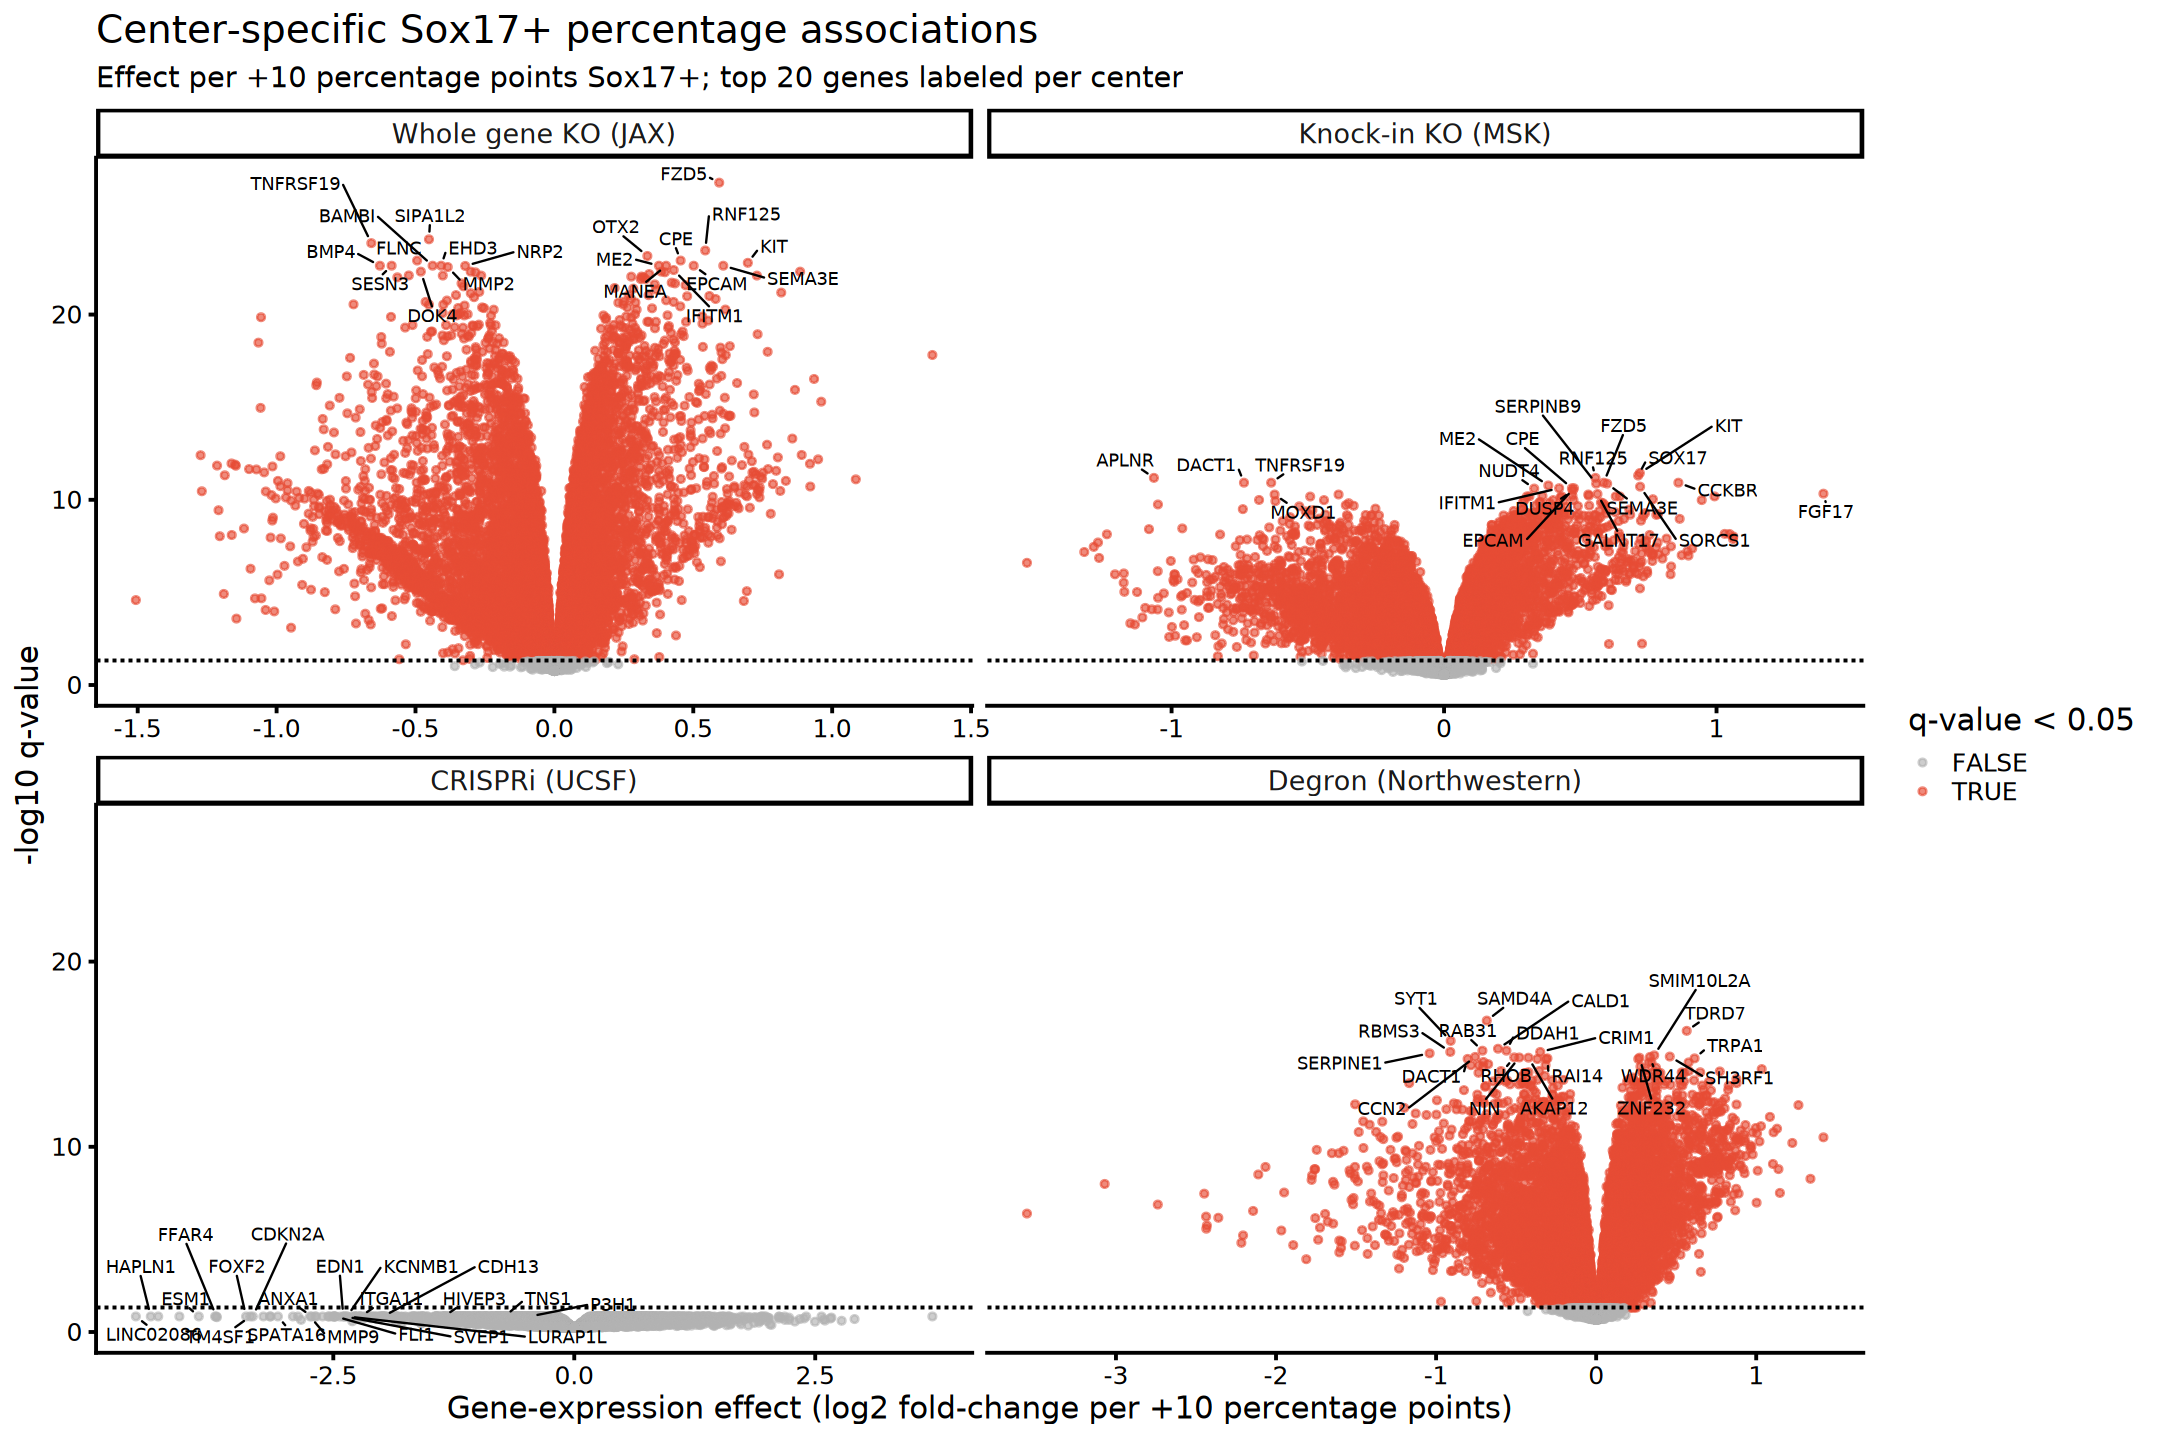

In [9]:
# Larger 2 x 2 volcano layout so each center has room for its top 20 labels.
options(
  repr.plot.width = 18,
  repr.plot.height = 12
)

center_volcano_plot <- ggplot(
  center_sox17_association_results,
  aes(
    x = logFC,
    y = -log10(pmax(qvalue, .Machine$double.xmin)),
    color = significant
  )
) +
  geom_point(alpha = 0.65, size = 1.3) +
  geom_text_repel(
    data = center_sox17_top20,
    aes(label = gene_label),
    color = "black",
    size = 3.6,
    box.padding = 0.4,
    point.padding = 0.25,
    min.segment.length = 0,
    max.overlaps = Inf,
    seed = 123,
    show.legend = FALSE
  ) +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed") +
  facet_wrap(~ analysis_center, nrow = 2, scales = "free_x") +
  scale_color_manual(values = c(`FALSE` = "grey70", `TRUE` = "#E64B35")) +
  labs(
    title = "Center-specific Sox17+ percentage associations",
    subtitle = "Effect per +10 percentage points Sox17+; top 20 genes labeled per center",
    x = "Gene-expression effect (log2 fold-change per +10 percentage points)",
    y = "-log10 q-value",
    color = "q-value < 0.05"
  ) +
  theme_classic(base_size = 18) +
  theme(
    plot.title = element_text(size = 23),
    plot.subtitle = element_text(size = 17),
    strip.text = element_text(size = 16),
    legend.position = "right"
  )

center_volcano_plot
ggsave(
  file.path(scripts_path, "EOMES_Sox17_percent_center_specific_volcano.png"),
  center_volcano_plot,
  width = 16,
  height = 11,
  dpi = 300
)


## Pairwise comparison of center-specific Sox17+ coefficients

Compare every pair of centers using the coefficient from the center-specific `expression ~ Sox17+ percentage` model. Each point is one gene tested in both centers, and both axes use the same effect unit: log2 expression change per +10 percentage points Sox17+. The dashed identity line indicates equal coefficients in the two centers.

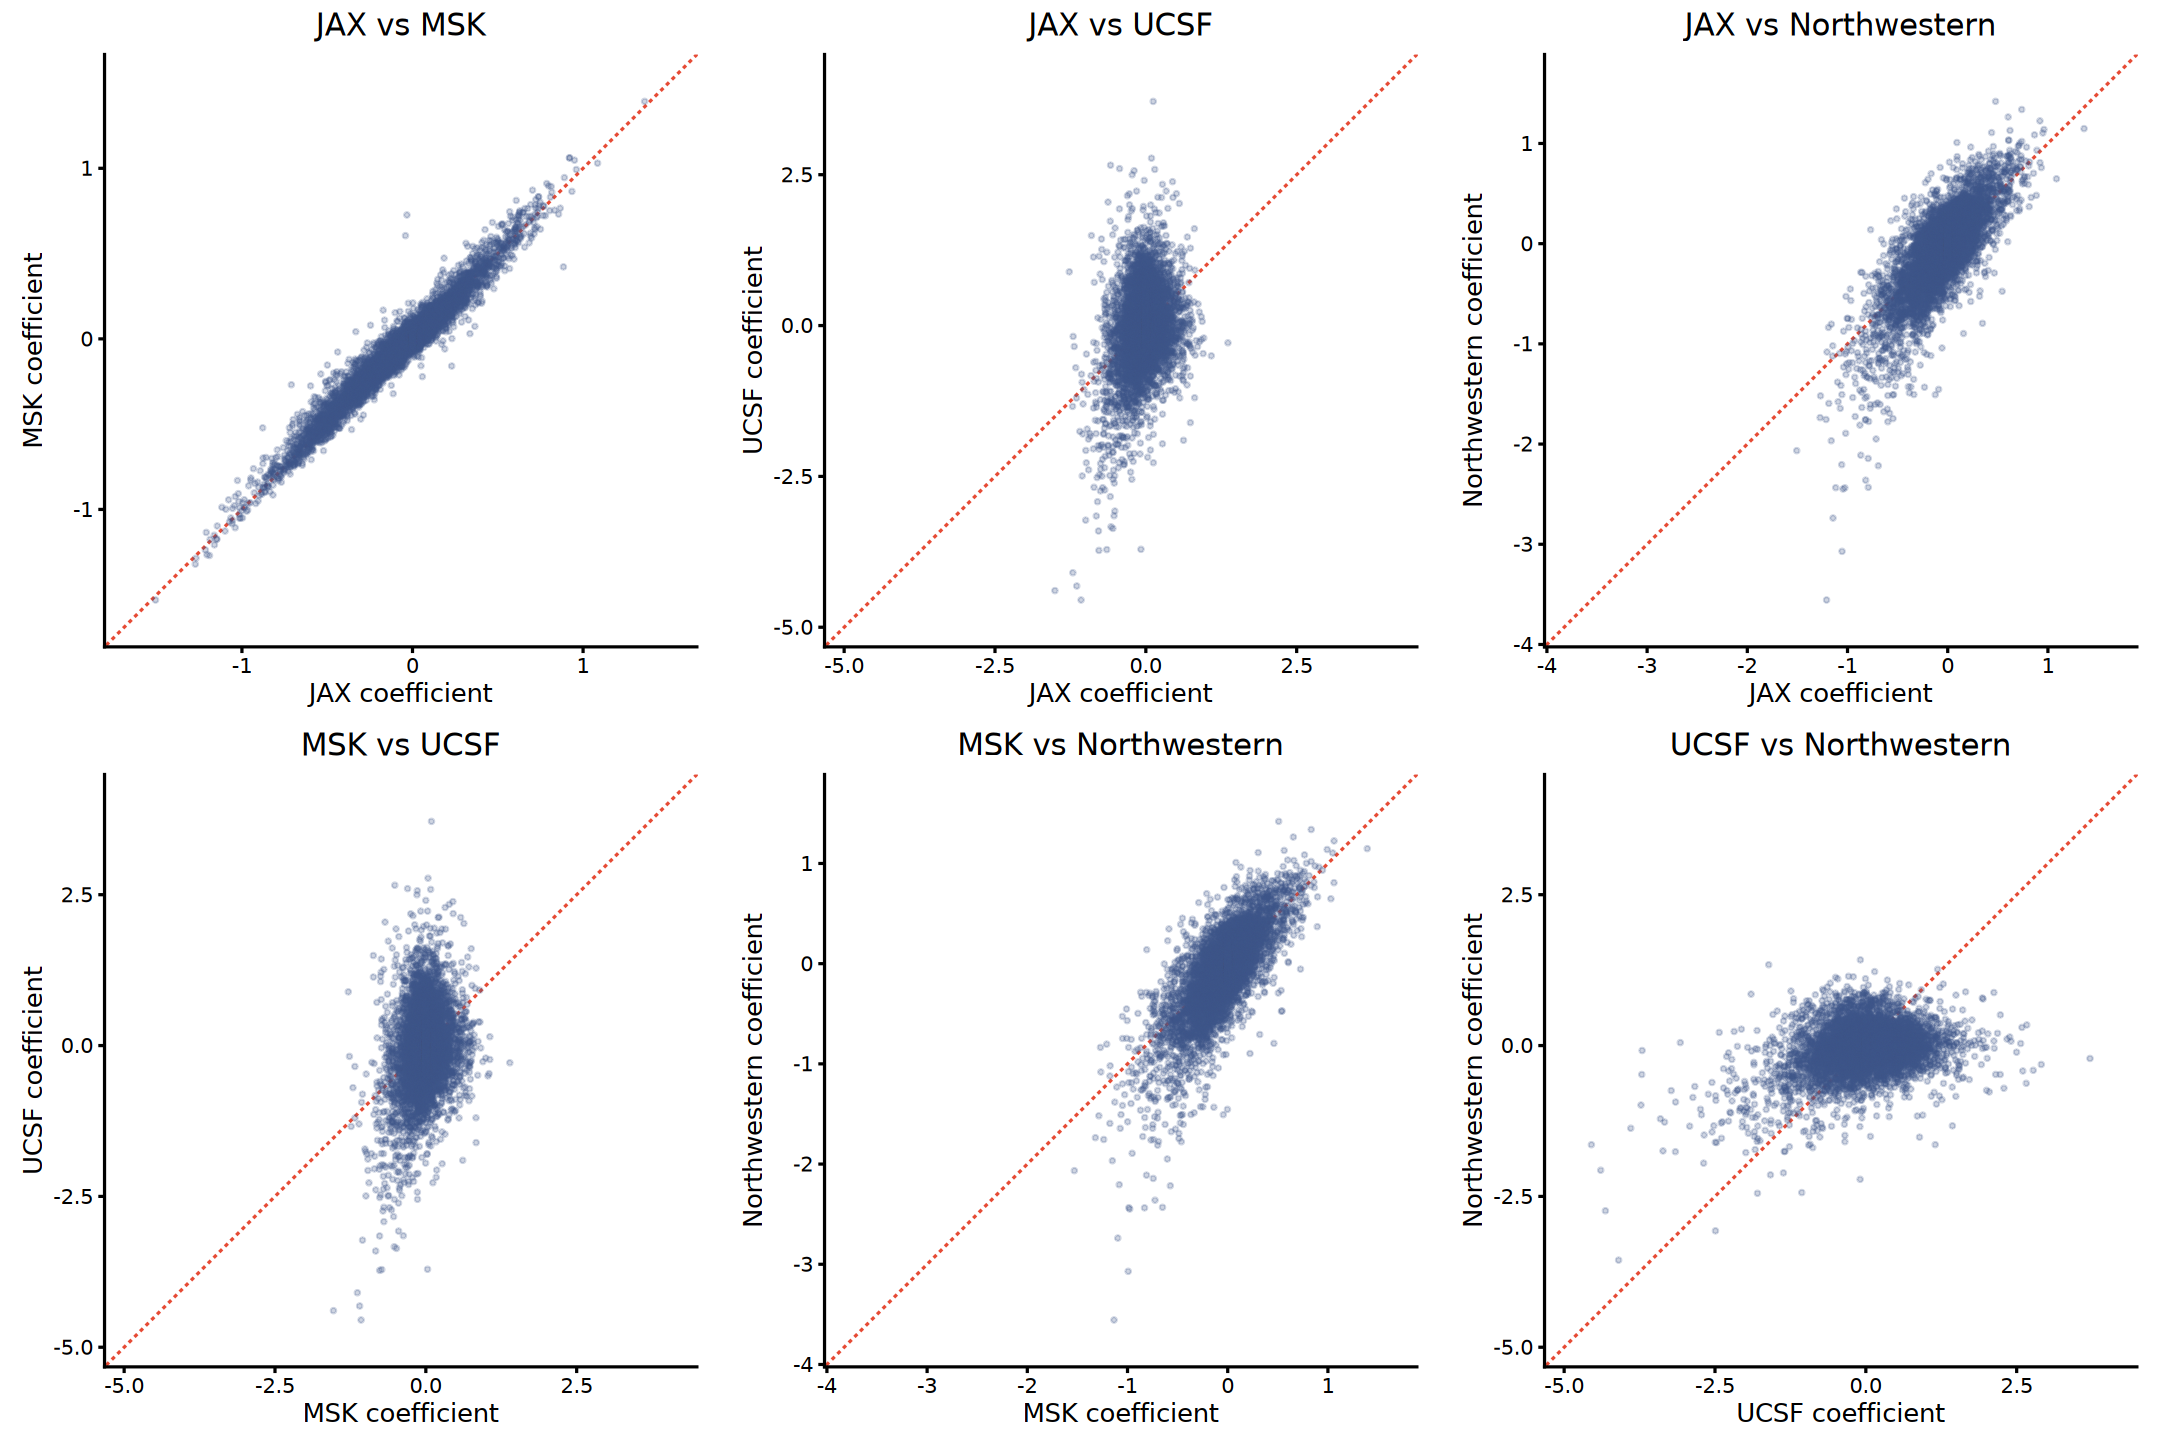

In [10]:
coefficient_center_labels <- c(
  "Whole gene KO (JAX)" = "JAX",
  "Knock-in KO (MSK)" = "MSK",
  "CRISPRi (UCSF)" = "UCSF",
  "Degron (Northwestern)" = "Northwestern"
  )

make_coefficient_pair_plot <- function(center_a, center_b) {
  label_a <- unname(coefficient_center_labels[center_a])
  label_b <- unname(coefficient_center_labels[center_b])

  center_a_results <- center_sox17_association_results %>%
    filter(analysis_center == center_a) %>%
    transmute(
      ensembl_gene_id,
      gene_label_a = gene_label,
      coefficient_a = logFC,
      qvalue_a = qvalue
    )

  center_b_results <- center_sox17_association_results %>%
    filter(analysis_center == center_b) %>%
    transmute(
      ensembl_gene_id,
      gene_label_b = gene_label,
      coefficient_b = logFC,
      qvalue_b = qvalue
    )

  pair_data <- inner_join(
    center_a_results,
    center_b_results,
    by = "ensembl_gene_id"
  ) %>%
    filter(is.finite(coefficient_a), is.finite(coefficient_b)) %>%
    mutate(
      gene_label = coalesce(gene_label_a, gene_label_b, ensembl_gene_id),
      center_a = label_a,
      center_b = label_b,
      pair = paste(label_a, label_b, sep = " vs ")
    ) %>%
    select(
      pair, center_a, center_b, ensembl_gene_id, gene_label,
      coefficient_a, coefficient_b, qvalue_a, qvalue_b
    )

  coefficient_limits <- range(
    c(pair_data$coefficient_a, pair_data$coefficient_b),
    finite = TRUE
  )
  coefficient_padding <- max(diff(coefficient_limits) * 0.04, 0.05)
  coefficient_limits <- coefficient_limits + c(-1, 1) * coefficient_padding

  pair_plot <- ggplot(pair_data, aes(x = coefficient_a, y = coefficient_b)) +
    geom_abline(
      intercept = 0, slope = 1,
      color = "#E64B35", linetype = "dashed", linewidth = 0.7
    ) +
    geom_point(color = "#3C5488", alpha = 0.25, size = 0.8) +
    coord_equal(xlim = coefficient_limits, ylim = coefficient_limits) +
    labs(
      title = paste(label_a, "vs", label_b),
      x = paste0(label_a, " coefficient"),
      y = paste0(label_b, " coefficient")
    ) +
    theme_classic(base_size = 15) +
    theme(plot.title = element_text(hjust = 0.5))

  list(
    data = pair_data,
    plot = pair_plot,
    file_stub = paste(label_a, label_b, sep = "-")
  )
}

coefficient_center_pairs <- combn(center_analysis_levels, 2, simplify = FALSE)
coefficient_pair_results <- purrr::map(
  coefficient_center_pairs,
  ~ make_coefficient_pair_plot(.x[1], .x[2])
)
coefficient_pair_data <- purrr::map_dfr(coefficient_pair_results, "data")
coefficient_pair_plots <- purrr::map(coefficient_pair_results, "plot")

fwrite(
  as.data.frame(coefficient_pair_data),
  file.path(scripts_path, "EOMES_Sox17_percent_center_specific_coefficient_pairwise.csv")
)

purrr::walk(coefficient_pair_results, function(pair_result) {
  ggsave(
    file.path(
      scripts_path,
      paste0(
        "EOMES_Sox17_percent_center_specific_coefficient_",
        pair_result$file_stub,
        ".png"
      )
    ),
    pair_result$plot,
    width = 7,
    height = 7,
    dpi = 300
  )
})

coefficient_pair_grid <- ggpubr::ggarrange(
  plotlist = coefficient_pair_plots,
  ncol = 3,
  nrow = 2,
  align = "hv"
)

options(repr.plot.width = 18, repr.plot.height = 12)
coefficient_pair_grid
ggsave(
  file.path(
    scripts_path,
    "EOMES_Sox17_percent_center_specific_coefficient_pairwise.png"
  ),
  coefficient_pair_grid,
  width = 18,
  height = 12,
  dpi = 300
)
